In [1]:
from httpx import AsyncClient
import asyncio
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import numpy as np

/home/salir/thisenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
async def test_concurrent_users(no_of_users : int, API_KEY, max_tokens = 128, ignore_eos = False):
    """
    In this test we will sent different number of requests at same time to server.
    This will Verify that the system remains stable and handles all requests 
    (either by serving them or correctly rate-limiting them).
    """
    async with AsyncClient(base_url="http://localhost:8000", timeout=600.0) as client:
        # 1. Define a helper function for a single user request
        async def make_request(user_id):
            start_time = time.perf_counter()
            response = await client.post(
                "/generate",
                headers={
                "Authorization": f"Bearer {API_KEY}",
                "Content-Type": "application/json"
            },
                json={
                "user_id": f"admin5",
                "prompt": "Hello AI",
                "max_tokens" : max_tokens,
                "ignore_eos" : ignore_eos,
            })

            end_time = time.perf_counter()
            duration = end_time - start_time

            return response, duration, user_id

        # 2. Prepare 50 concurrent tasks
        tasks = [make_request(i) for i in range(no_of_users)]
        
        # 3. Fire them ALL at once
        results = await asyncio.gather(*tasks)

        # 4. Assertions
        assert len(results) == no_of_users

        latencies = []
        
        # Check that valid responses are 200 OK
        for response, duration, user_id in results:
            if response.status_code not in [200, 429]:
                print(response.text)
            assert response.status_code in [200, 429]

            if response.status_code == 200:
                latencies.append(duration)
        
        avg_latency = 0
        if latencies:
            avg_latency = sum(latencies) / len(latencies)

        return avg_latency

-- Running the warm-up test
 ----- Starting Main test ----
this is average latencies :  [np.float64(4.380074747666716), np.float64(4.700282364166658), np.float64(4.931707666833347), np.float64(5.147386463833357), np.float64(4.9708112453333415), np.float64(4.887580277000002), np.float64(5.0059834473333735), np.float64(5.065845097499978), np.float64(5.153135289333363), np.float64(5.224360670499986), np.float64(5.172105150333304), np.float64(4.789315170000009), np.float64(5.383631407333344), np.float64(5.436862432166606)]


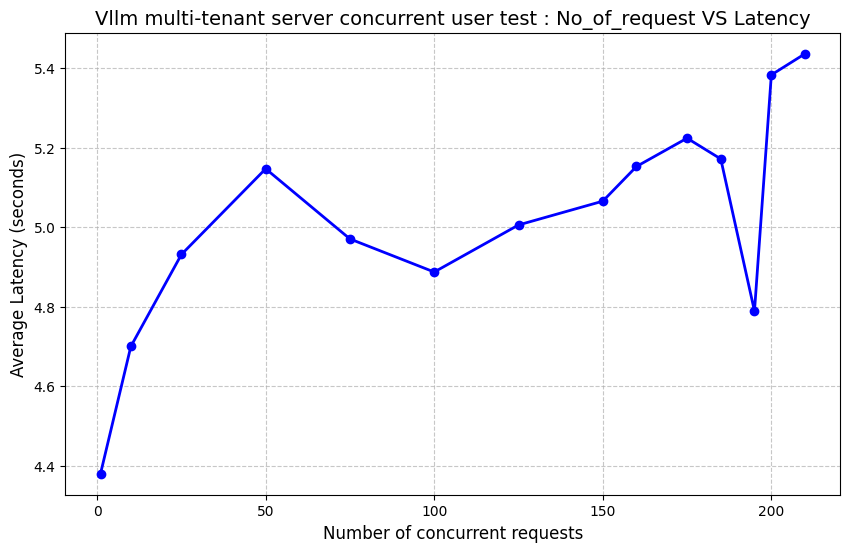

In [4]:
async def run_benchmarks():   
    no_of_requests = [1, 10, 25, 50, 75, 100, 125, 150, 160, 175, 185, 195, 200, 210]
    avg_latencies = []
    API_KEY = "that-128"

    print("-- Running the warm-up test")
    await test_concurrent_users(no_of_users=1, API_KEY=API_KEY)
    print(" ----- Starting Main test ----")

    for i in no_of_requests:
        temp_latencies = []
        for _ in range(3):
            avg = await test_concurrent_users(no_of_users=i, API_KEY=API_KEY)
            temp_latencies.append(avg)
            await asyncio.sleep(1)
        avg_latencies.append(np.mean(temp_latencies))

    return no_of_requests, avg_latencies

users, avg_latencies = await run_benchmarks()

print("this is average latencies : ",avg_latencies)

plt.figure(figsize=(10, 6))
plt.plot(users, avg_latencies, marker='o', linestyle='-', color='b', linewidth=2)
plt.title("Vllm multi-tenant server concurrent user test : No_of_request VS Latency", fontsize=14)
plt.xlabel("Number of concurrent requests", fontsize=12)
plt.ylabel("Average Latency (seconds)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("firsttest.png", dpi=300, bbox_inches="tight")

In [5]:
async def test_long_prompt_latency(API_KEY, prompt : str, prompt_len : int, max_tokens = 128, ignore_eos = False):
    '''
    In this test we will sent long prompts, to check the latency of the system for different request.
    Also to check does the system is capable of handling long prompts.
    '''
    async with AsyncClient(base_url="http://localhost:8000", timeout=600.0) as client:
        start_time = time.perf_counter()
        response = await client.post(
            "/generate", 
            headers={
            "Authorization": f"Bearer {API_KEY}",
            "Content-Type": "application/json"
        },
            json={
            "user_id": "attacker_01",
            "prompt": prompt,
            "max_tokens" : max_tokens,
            "ignore_eos" : ignore_eos
        })

        end_time = time.perf_counter()
        duration = end_time - start_time

    return duration

 -- Warm-up -- 

Testing the system for 16 number of tokens . . .

Testing the system for 64 number of tokens . . .

Testing the system for 128 number of tokens . . .

Testing the system for 256 number of tokens . . .

Testing the system for 512 number of tokens . . .

Testing the system for 1024 number of tokens . . .

Testing the system for 1536 number of tokens . . .

Testing the system for 2000 number of tokens . . .


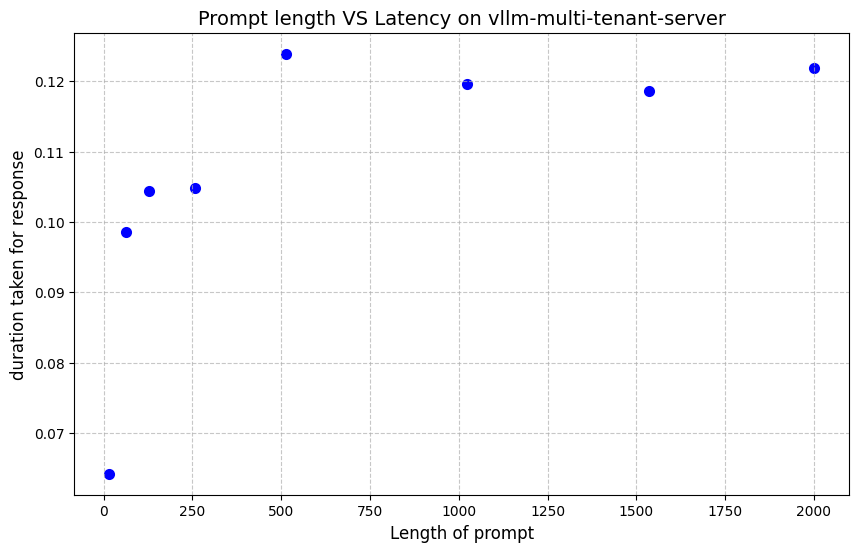

In [6]:
async def run_benchmarks():
    target_lengths = [16, 64, 128, 256, 512, 1024, 1536, 2000]
    API_KEY = "that-129"

    tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")
    token_id = tokenizer.encode("Hello")[0]

    final_latencies = []

    print(" -- Warm-up -- ")
    await test_long_prompt_latency(API_KEY=API_KEY, prompt="warmup", prompt_len=1)
    
    for target in target_lengths:
        print(f"\nTesting the system for {target} number of tokens . . .")

        total_token_ids = [token_id] * target
        temp_prompt = tokenizer.decode(total_token_ids)

        temp_latencies = []
        for _ in range(3):
            duration = await test_long_prompt_latency(API_KEY=API_KEY, prompt=temp_prompt, prompt_len=target, max_tokens=1)
            temp_latencies.append(duration)
            await asyncio.sleep(0.5)

        final_latencies.append(np.mean(temp_latencies))

    return target_lengths, final_latencies


prompt_lengths, latencies = await run_benchmarks()

plt.figure(figsize=(10, 6))
plt.scatter(prompt_lengths, latencies, marker='o', linestyle='-', color='b', linewidth=2)
plt.title("Prompt length VS Latency on vllm-multi-tenant-server", fontsize=14)
plt.xlabel("Length of prompt", fontsize=12)
plt.ylabel("duration taken for response", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("secondtest.png", dpi=300, bbox_inches="tight")